# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.portfolio as portfolio_module
import model.analysis.profit as profit_analysis
import model.data.loader as loader

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(portfolio_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.MortalityTable()

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Portfolio Setup

In [5]:
portfolio = loader.load_portfolio_csv(
    "../data/sample_portfolio.csv"
)

portfolio

=== PORTFOLIO SUMMARY ===
PV Premiums : 1,388,689,009.69
PV Claims   : 1,319,193,793.29
Net Value   : 69,495,216.39

=== EMERGENCE PREVIEW ===


,t,expected_premium,expected_claim,expected_lapse,pv_net,cum_profit
0,0,1.000128e+08,4.426517e+07,818.420000,5.574762e+07,5.574762e+07
1,1,9.785779e+07,4.645773e+07,495.119459,4.990297e+07,1.056506e+08
2,2,9.638287e+07,4.915605e+07,462.008988,4.451581e+07,1.501664e+08
3,3,9.495360e+07,5.200806e+07,430.994864,3.930126e+07,1.894677e+08
4,4,9.356409e+07,5.501790e+07,401.942103,3.424780e+07,2.237155e+08
5,5,9.039199e+07,5.645490e+07,248.005589,2.927442e+07,2.529899e+08
6,6,8.588417e+07,5.919049e+07,228.133257,2.235553e+07,2.753454e+08
7,7,8.260079e+07,6.207358e+07,211.410139,1.669050e+07,2.920359e+08
8,8,7.832493e+07,6.456919e+07,200.903296,1.085891e+07,3.028948e+08
9,9,7.608086e+07,6.396707e+07,186.384880,9.284210e+06,3.121790e+08


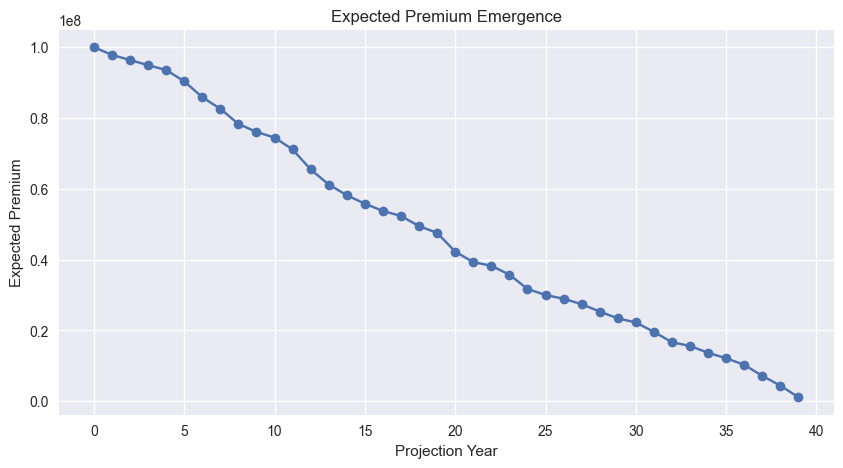

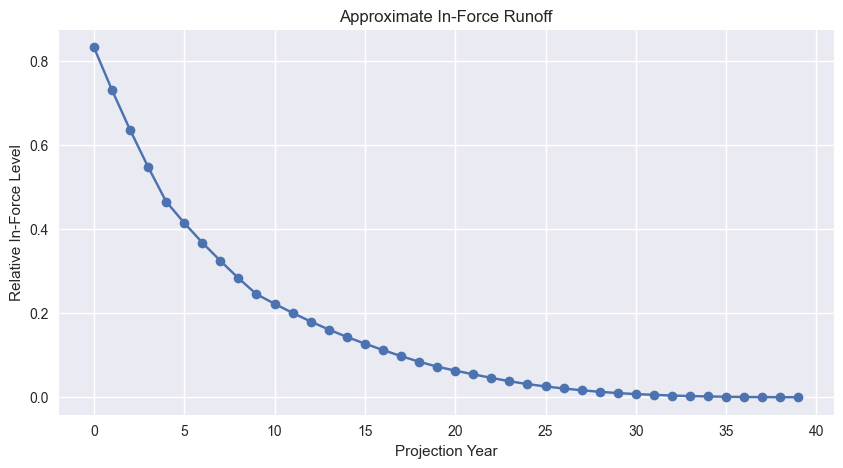

In [6]:
# Run portfolio valuation
result = portfolio.value(
    assumptions,
    return_breakdown=True
)

# Build emergence dataframe
df = profit_analysis.build_profit_dataframe(result)

# =========================
# Summary metrics
# =========================

print("=== PORTFOLIO SUMMARY ===")
print(f"PV Premiums : {result.pv_premiums:,.2f}")
print(f"PV Claims   : {result.pv_claims:,.2f}")
print(f"Net Value   : {result.net_value:,.2f}")
print()

# =========================
# Emergence preview
# =========================

print("=== EMERGENCE PREVIEW ===")

display_cols = [
    "t",
    "expected_premium",
    "expected_claim",
    "expected_lapse",
    "pv_net",
    "cum_profit"
]

display(df[display_cols].head(10))

# =========================
# Premium emergence chart
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    df["t"],
    df["expected_premium"],
    marker="o"
)

plt.title("Expected Premium Emergence")
plt.xlabel("Projection Year")
plt.ylabel("Expected Premium")

plt.grid(True)

plt.show()

# =========================
# In-force runoff chart
# =========================

plt.figure(figsize=(10, 5))

if df["expected_lapse"].sum() > 0:

    runoff = 1 - (
        df["expected_lapse"].cumsum()
        / df["expected_lapse"].sum()
    )

else:

    runoff = [1.0] * len(df)

plt.plot(
    df["t"],
    runoff,
    marker="o"
)

plt.title("Approximate In-Force Runoff")
plt.xlabel("Projection Year")
plt.ylabel("Relative In-Force Level")

plt.grid(True)

plt.show()

# Portfolio Inspection

In [7]:
len(portfolio.policies)

250

In [8]:
portfolio.policies[0]

Policy(age=60, term=12, sum_assured=25000.0, premium=291.0, gender=M, smoker_status=Smoker, product_type=Endowment, weight=63)

# Portfolio Valuation

In [9]:
portfolio_result = portfolio.value(
    assumptions,
    return_breakdown=True
)

portfolio_result

PortfolioResult(policies=250, net_value=69495216.39)

# Portfolio DataFrame

In [10]:
portfolio_df = profit_analysis.build_profit_dataframe(
    portfolio_result
)

portfolio_df.head()

,t,age,discount_factor,lapse_rate,expected_premium,expected_claim,expected_lapse,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow
0,0,60,1.000000,0.0,1.000128e+08,4.426517e+07,818.420000,5.574762e+07,1.000128e+08,4.426517e+07,5.574762e+07,5.574762e+07,5.574762e+07
1,1,61,0.970874,0.0,9.785779e+07,4.645773e+07,495.119459,5.140006e+07,9.500756e+07,4.510459e+07,4.990297e+07,1.056506e+08,1.071477e+08
2,2,62,0.942596,0.0,9.638287e+07,4.915605e+07,462.008988,4.722682e+07,9.085010e+07,4.633429e+07,4.451581e+07,1.501664e+08,1.543745e+08
3,3,63,0.915142,0.0,9.495360e+07,5.200806e+07,430.994864,4.294554e+07,8.689600e+07,4.759474e+07,3.930126e+07,1.894677e+08,1.973200e+08
4,4,64,0.888487,0.0,9.356409e+07,5.501790e+07,401.942103,3.854620e+07,8.313049e+07,4.888269e+07,3.424780e+07,2.237155e+08,2.358662e+08


# Profit Signature

In [11]:
portfolio_signature = profit_analysis.add_profit_signature(
    portfolio_df
)

portfolio_signature.head()

,t,age,discount_factor,lapse_rate,expected_premium,expected_claim,expected_lapse,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow,profit_pct
0,0,60,1.000000,0.0,1.000128e+08,4.426517e+07,818.420000,5.574762e+07,1.000128e+08,4.426517e+07,5.574762e+07,5.574762e+07,5.574762e+07,0.802179
1,1,61,0.970874,0.0,9.785779e+07,4.645773e+07,495.119459,5.140006e+07,9.500756e+07,4.510459e+07,4.990297e+07,1.056506e+08,1.071477e+08,0.718078
2,2,62,0.942596,0.0,9.638287e+07,4.915605e+07,462.008988,4.722682e+07,9.085010e+07,4.633429e+07,4.451581e+07,1.501664e+08,1.543745e+08,0.640559
3,3,63,0.915142,0.0,9.495360e+07,5.200806e+07,430.994864,4.294554e+07,8.689600e+07,4.759474e+07,3.930126e+07,1.894677e+08,1.973200e+08,0.565525
4,4,64,0.888487,0.0,9.356409e+07,5.501790e+07,401.942103,3.854620e+07,8.313049e+07,4.888269e+07,3.424780e+07,2.237155e+08,2.358662e+08,0.492808


# Summary Metrics

In [12]:
profit_analysis.summary_metrics(portfolio_df)

{'total_pv_profit': np.float64(69495216.39309295),
 'total_cash_profit': np.float64(-180556186.02485698),
 'peak_profit_year': np.int64(0)}

# Visualisations

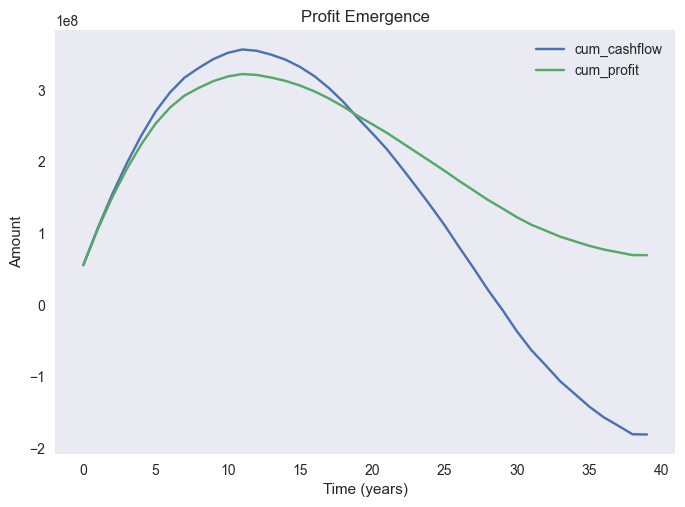

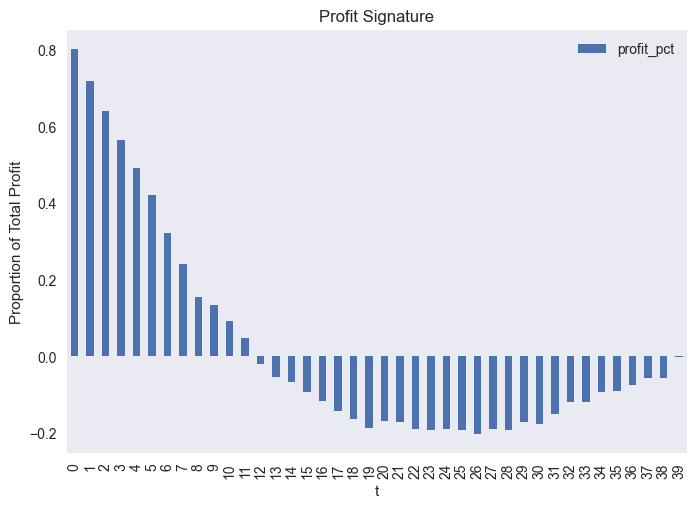

In [13]:
# Profit Emergence

portfolio_df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

portfolio_signature.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()